# EDA — jointure rendements × climat

Chemin fiable (sans Jupyter) : `python -m agri_climat eda`

Ce notebook charge le CSV déjà joint. **Pas de `plt.show()`** : sous Windows ça ouvre Tk et peut rester bloqué des minutes.

In [1]:
%matplotlib inline

from agri_climat.data.join import (
    climate_extremes,
    coverage_by_crop_geo,
    missingness,
    yield_summary_by_crop,
)
from agri_climat.eda_preview import load_joined_table, plot_wheat_vs_precip_z

joined = load_joined_table()
joined.head()

,year,geo,geo_label,crop_code,crop_label,area_kha,production_kt,yield_t_ha,imputed,temp_mean_c,...,precip_mm_anom,precip_mm_z,et0_mm_anom,et0_mm_z,temp_mean_growing_c_anom,temp_mean_growing_c_z,precip_growing_mm_anom,precip_growing_mm_z,et0_growing_mm_anom,et0_growing_mm_z
0,2000,BE3,Wallonie,C1110,Froment et épeautre,139.0,1091.93,7.856,False,10.358,...,116.9,0.933,-63.0,-1.185,-0.44,-0.706,123.9,1.575,-58.0,-1.246
1,2001,BE3,Wallonie,C1110,Froment et épeautre,128.4,1039.99,8.100,False,9.876,...,141.4,1.129,-43.7,-0.822,-0.79,-1.261,66.0,0.839,-31.6,-0.679
2,2002,BE3,Wallonie,C1110,Froment et épeautre,134.8,1111.31,8.244,False,10.498,...,103.5,0.826,-41.4,-0.779,-0.43,-0.690,-22.3,-0.283,-46.3,-0.995
3,2003,BE3,Wallonie,C1110,Froment et épeautre,135.3,1144.45,8.459,False,10.376,...,-194.2,-1.550,77.1,1.451,0.96,1.526,-71.5,-0.909,66.5,1.429
4,2004,BE3,Wallonie,C1110,Froment et épeautre,141.1,1239.07,8.782,False,9.802,...,-102.1,-0.815,-18.8,-0.354,-0.42,-0.665,-17.5,-0.223,-19.4,-0.418


In [2]:
coverage_by_crop_geo(joined)

geo,BE3,BE31,BE32,BE33,BE34,BE35
crop_label,,,,,,
Betterave sucrière,25,25,25,25,25,25
Colza,25,25,25,25,25,25
Froment et épeautre,25,25,25,25,25,25
Maïs fourrager,25,25,25,25,25,25
Maïs grain,14,14,14,14,14,14
Orge,25,25,25,25,25,25
Orge d'hiver,14,14,14,14,14,14
Pomme de terre,25,25,25,25,25,25


In [3]:
yield_summary_by_crop(joined)

,crop_label,n,min_t_ha,median_t_ha,max_t_ha,missing
0,Betterave sucrière,25,53.96,77.80,96.93,0
1,Colza,25,3.02,3.83,4.54,0
2,Froment et épeautre,24,6.50,8.38,9.22,1
3,Maïs fourrager,23,38.82,44.43,49.34,2
4,Maïs grain,14,7.40,8.55,10.14,0
5,Orge,25,6.07,7.79,8.89,0
6,Orge d'hiver,14,6.15,8.13,9.20,0
7,Pomme de terre,25,20.88,42.73,50.21,0


In [4]:
climate_extremes(joined, geo="BE3")

,indicateur,annee_min,z_min,annee_max,z_max
0,température saison (z),2021,-1.824,2018,2.345
1,précipitations saison (z),2018,-1.821,2024,2.320
2,ET0 saison (z),2000,-1.246,2020,2.107


In [5]:
missingness(joined)

,colonne,n_na,part_na
0,yield_t_ha,31,0.0290
1,production_kt,12,0.0112
2,area_kha,6,0.0056


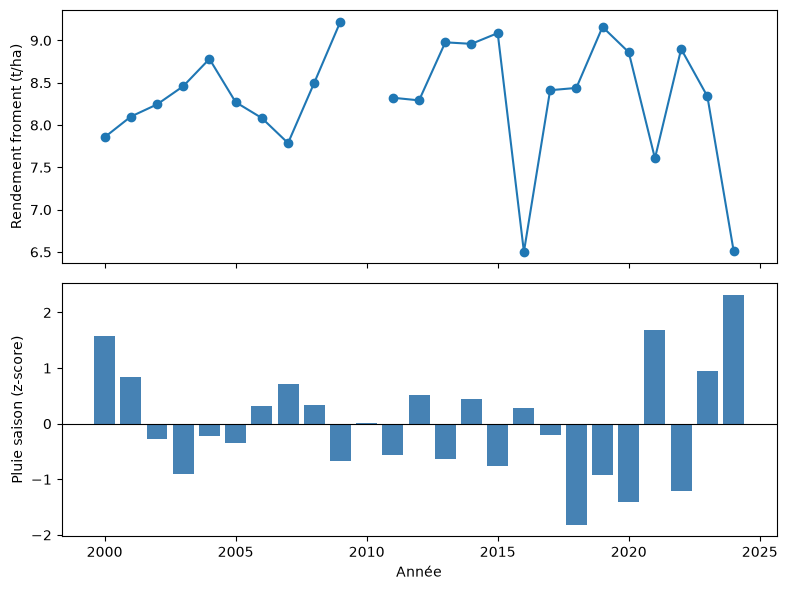

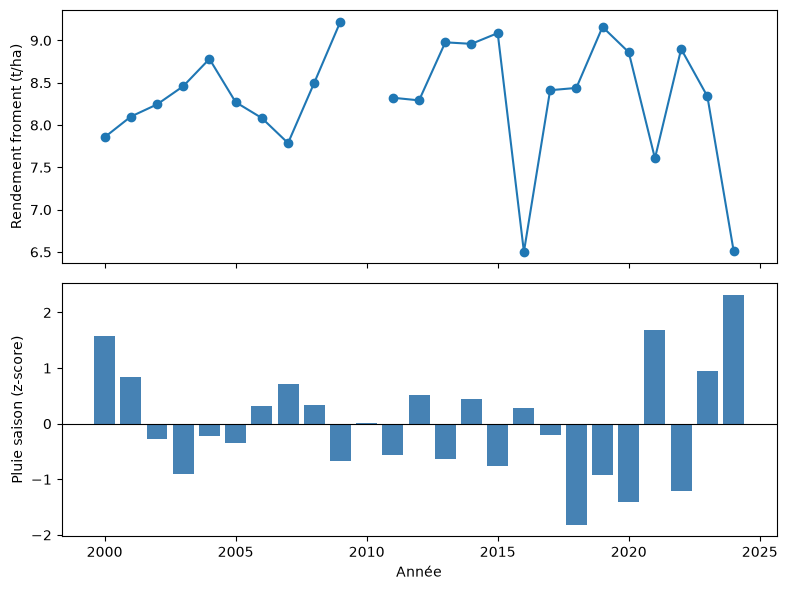

In [6]:
fig = plot_wheat_vs_precip_z(joined)
fig